In [9]:
import os
# Default values defined in the notebook for Station and OSVAS install:
OSVAS='/home/alvaro/master/TFM/OSVAS'  # Main OSVAS path
Station_name='Cabauw'

# If an environment variable STATION or OSVAS exists, override the default
Station_name = os.getenv("STATION_NAME", Station_name)
OSVAS = os.getenv("OSVAS", OSVAS)

key_path = os.path.join(OSVAS,"KMNI_token.txt")
api_key = open(key_path, "r").readline().strip()

start_date = pd.to_datetime('2017-12-01 00:00:00', utc=True)
end_date = pd.to_datetime('2018-12-31 23:59:59', utc=True)
print(f"Creating Validation files for: {Station_name} with OSVAS installation in {OSVAS}")

Creating Validation files for: Cabauw with OSVAS installation in /home/alvaro/master/TFM/OSVAS


In [8]:
# Necessary functions
from datetime import date, datetime, timedelta, timezone
from dateutil.relativedelta import relativedelta
from functools import reduce
import matplotlib
import matplotlib.pyplot as plt
from netCDF4 import Dataset, date2num
import numpy as np
import os
import pandas as pd
import pytz
import re
import requests
import sqlite3
import tempfile
import xarray as xr
import xml.etree.ElementTree as ET
import yaml

def download_file(endpoint, headers, filename, download_directory='./.nc_data'):
    """
        Downloads the file filename from the endpoint to download_directory. If open is set to true, 
        the function returns the opened Netcdf Dataset.

        Parameters:
            endpoint: The url of the endpoint to receive the list of files
            headers: Dictionary with request headers, Authentication is mandatory with the corresponding token.
            download_directory: The path to the directory where files will be downloaded.
    """
    result = requests.get('/'.join((endpoint, filename, 'url')), headers=headers)
    r = requests.get(result.json()['temporaryDownloadUrl'])
    r.raise_for_status()
    with tempfile.NamedTemporaryFile(suffix=".nc") as f:
        f.write(r.content)
        f.flush()
        ds = xr.open_dataset(f.name)  # or "h5netcdf"
    return ds

def fetch_file_list(endpoint, headers, payload):
    """
        File list returned by endpoint satisfying payload criteria.
        
        Parameters:
            endpoint: The url of the endpoint to receive the list of files
            headers: Dictionary with request headers, Authentication is mandatory with the corresponding token
            payload: Dictionary with optional parameters for the get request.
        
        return: A list with the filenames that satisfy the given criteria. This filenames can then be retrieved calling another KMNI API endpoint
        
    """
    file_list = []
    truncated = True
    while truncated:
        result = requests.get(endpoint, headers=headers, params=payload)
        result.raise_for_status()
        result = result.json()
        file_list += [i['filename'] for i in result['files']]
        truncated = result['isTruncated']
        if truncated:
            payload += {'nextPageToken': result['nextPageToken']}
    print(f"{len(file_list)} files will be processed")
    return file_list



def retrieve_data(endpoint, start_date, end_date, key):
    """
    Generates a dataset with the data collected from endpoint between start_date and end_date. It requires the api_key parameter 
    to make the requests to the service.
    """
    dataset_name = endpoint.split("/datasets/")[1].split("/")[0]
    dataset_version = endpoint.split("/versions/")[1].split("/")[0]
    start_file = (f"{dataset_name}_{dataset_version}_{start_date:%Y%m}.nc")
    end_file = (f"{dataset_name}_{dataset_version}_{end_date:%Y%m}.nc")
    months = pd.date_range(start=start_date, end=end_date, freq="MS")
    filenames = [f"{dataset_name}_{dataset_version}_{date:%Y%m}.nc" for date in months]
    headers={"Authorization": api_key}
    payload = {
        'maxKeys': '1000',
        'sorting': 'asc',
        'orderBy': 'filename',
        'begin': start_file,
        'end': end_file
    }
    file_list = fetch_file_list(endpoint, headers, payload)
    files = []
    for file in filenames:
        if file in file_list:
            files.append(download_file(endpoint, headers, file).drop_vars('valid_dates'))
        else:
            print(f"⚠️ {file} not found in KMNI service, data for this month will be filled with nan")
    ds_values = xr.concat(files, dim='time', data_vars='minimal').sortby('time')
    ds_values = ds_values.sel(time=slice(start_date.tz_localize(None), end_date.tz_localize(None)))
    #ds_values['SWD'] = ds_values['SWD'].clip(min=0)
    #ds_values['LWD'] = ds_values['SWD'].clip(min=0)
    return ds_values

In [53]:
# Temperatura y humedad, carga de datos:
doi = "https://api.dataplatform.knmi.nl/open-data/v1/datasets/cesar_soil_heat_lb1_t10/versions/v1.0/files"
temperature = retrieve_data(doi, start_date, end_date, api_key)

doi = "https://api.dataplatform.knmi.nl/open-data/v1/datasets/cesar_soil_water_lb1_t10/versions/v1.1/files"
moisture = retrieve_data(doi, start_date, end_date, api_key)

13 files will be processed
13 files will be processed


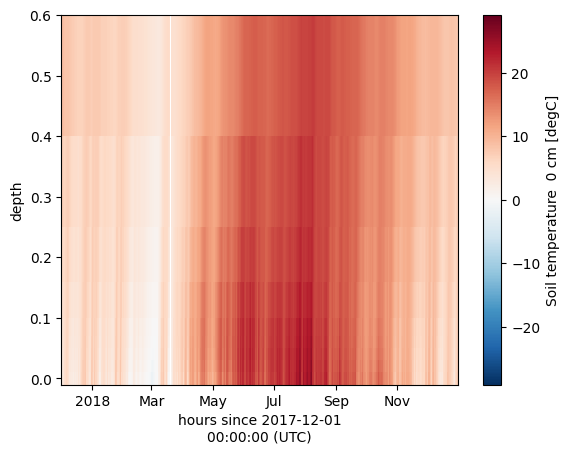

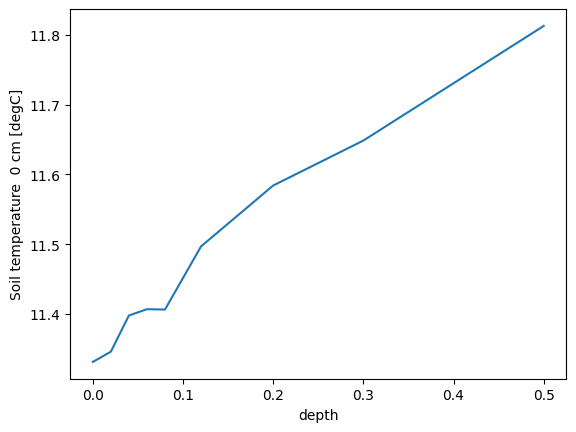

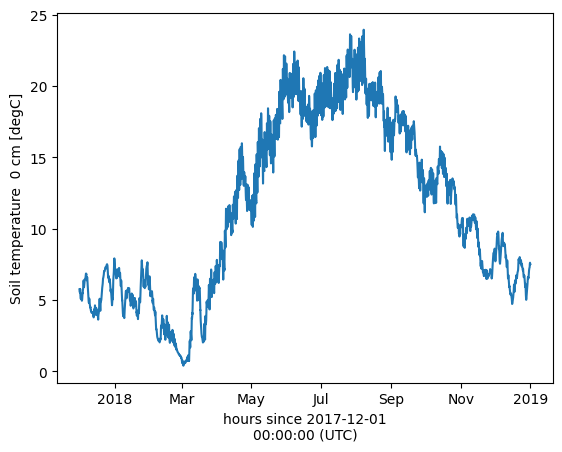

In [68]:
# Prepate temperature dataset (depth,time)
temperature = temperature[[v for v in temperature.data_vars if (v.startswith("TS")) and not (temperature[v].isnull().all())]]
depth = [int(v[2::])*.01 for v in temperature.data_vars]
temp = xr.concat([temperature[v] for v in temperature.data_vars], dim='depth').assign_coords(depth=depth)
temp.plot()
plt.show()
temp.mean('time').plot()
plt.show()
temp.mean('depth').plot()
plt.show()

In [55]:
moisture

<xarray.Dataset> Size: 6MB
Dimensions:          (time: 57024, nv: 2)
Coordinates:
  * time             (time) datetime64[ns] 456kB 2017-12-01 ... 2018-12-31T23...
Dimensions without coordinates: nv
Data variables: (12/23)
    GWLEBN           (time) float32 228kB -1.075 -1.075 -1.076 ... -1.247 -1.247
    GWLEBS           (time) float32 228kB -0.1052 -0.1055 ... -0.2766 -0.2767
    GWLSLN           (time) float32 228kB -1.429 -1.429 -1.429 ... -1.506 -1.506
    GWLW1N           (time) float32 228kB -1.044 -1.045 -1.045 ... -1.338 -1.338
    GWLW1S           (time) float32 228kB -0.2843 -0.285 ... -0.5784 -0.5781
    GWLW2N           (time) float32 228kB -1.052 -1.053 -1.053 ... -1.325 -1.325
    ...               ...
    TH56             (time) float32 228kB 0.6926 0.6995 0.7109 ... 0.6881 0.6797
    date             (time) int32 228kB 20171201 20171201 ... 20181231 20181231
    iso_dataset      |S1 1B b''
    product          |S1 1B b''
    station_details  |S1 1B b''
    time_bnds        (time, nv) datetime64[ns] 912kB 2017-12-01 ... 2019-01-01
Attributes:
    institution:              Royal Netherlands Meteorological Institute (KNMI)
    comment:                  none
    Conventions:              CF-1.6
    location:                 CESAR observatory, the Netherlands
    file_creation_date_time:  20180222 16:27:11 (UTC)
    references:               cesar_soil_water_lb1_t10_v1.1.pdf @ http://www....
    featureType:              timeSeries
    history:                  Mon Nov 18 11:55:32 2019: ncatted -a format_ver...
    NCO:                      netCDF Operators version 4.7.5 (Homepage = http...

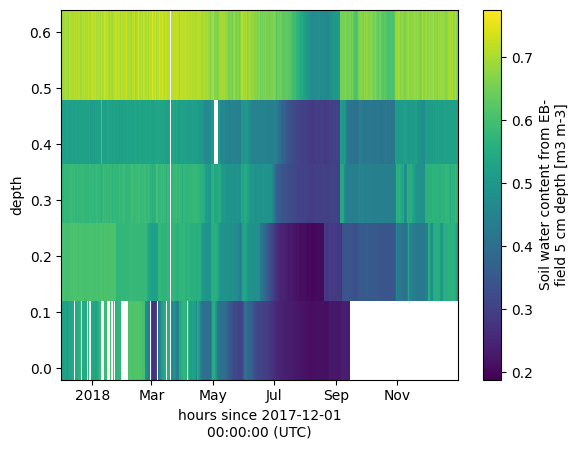

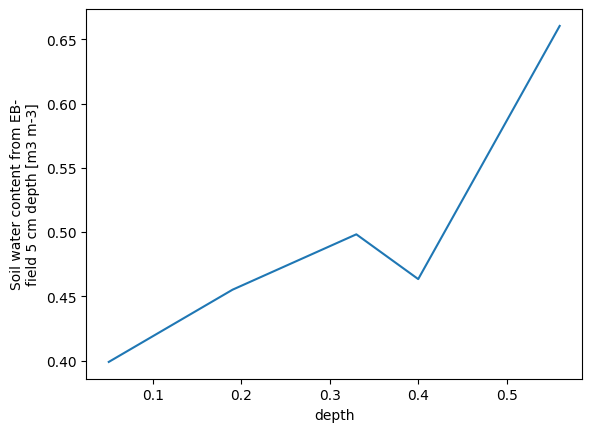

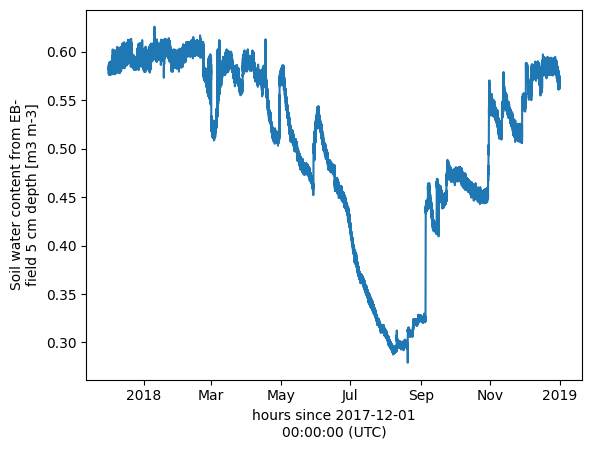

In [69]:
# Prepate temperature dataset (depth,time)
moisture = moisture[[v for v in moisture.data_vars if (v.startswith("TH")) and not (moisture[v].isnull().all())]]
depth = [int(v[2::])*.01 for v in moisture.data_vars]
swc = xr.concat([moisture[v] for v in moisture.data_vars], dim='depth').assign_coords(depth=depth)
swc.plot()
plt.show()
swc.mean('time').plot()
plt.show()
swc.mean('depth').plot()
plt.show()

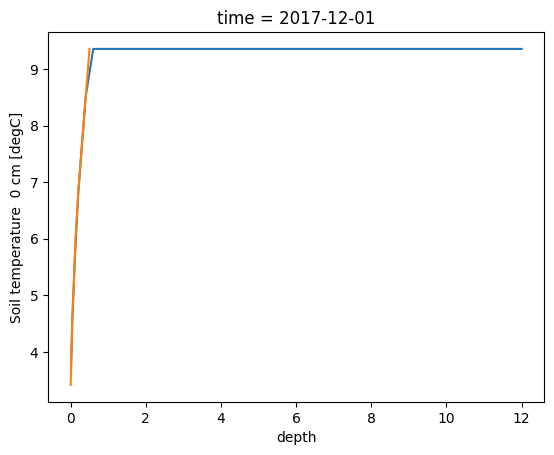

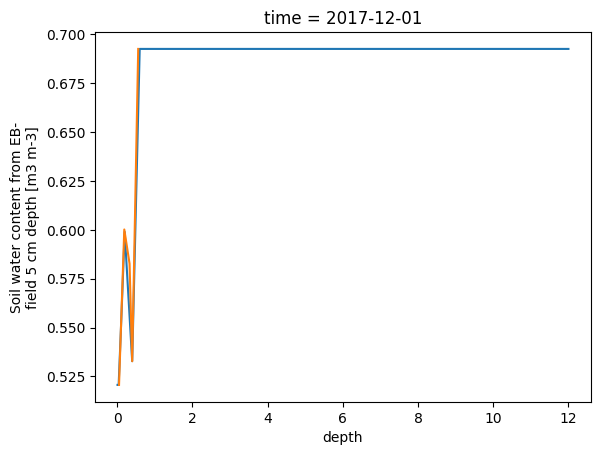

In [166]:
#Simple approach Linear interpolation + Constant outside the interval (just for initialization, not good for validation)
XSOILGRID = [0.01,0.04,0.10,0.20,0.40,0.60,0.80,1.00,1.50,2.00,3.00,5.00,8.00,12.0]
d_min = temp.depth.min()
d_max = temp.depth.max()
t_interp = temp.interp(depth=XSOILGRID, method = 'linear')
up_const = temp.sel(depth=d_min)
down_const = temp.sel(depth=d_max)
t_interp0 = t_interp.where(t_interp.depth <= d_max, down_const).where(t_interp.depth >= d_min, up_const).isel(time=0)
t_interp0.plot()
temp.isel(time = 0).plot()
plt.show()
swc_interp = swc.interp(depth=XSOILGRID, method = 'linear')
d_min = swc.depth.min()
d_max = swc.depth.max()
up_const = swc.sel(depth=d_min)
down_const = swc.sel(depth=d_max)
swc_interp0 = swc_interp.where(swc_interp.depth <= d_max, down_const).where(swc_interp.depth >= d_min, up_const).isel(time=0)
swc_interp0.plot()
swc.isel(time=0).plot()
plt.show()

In [168]:
t_interp0 + 273.15

<xarray.DataArray 'TS00' (depth: 14)> Size: 112B
array([276.8744519 , 277.63836136, 278.6530086 , 279.9549221 ,
       281.66715946, 282.50451603, 282.50451603, 282.50451603,
       282.50451603, 282.50451603, 282.50451603, 282.50451603,
       282.50451603, 282.50451603])
Coordinates:
  * depth    (depth) float64 112B 0.01 0.04 0.1 0.2 0.4 ... 2.0 3.0 5.0 8.0 12.0
    time     datetime64[ns] 8B 2017-12-01
Attributes:
    units:          degC
    long_name:      Soil temperature  0 cm
    standard_name:  soil_temperature
    cell_methods:   time: mean

In [213]:
fc = 0.468
wilt = 0.253
(swc_interp0 - wilt)/(fc - wilt)

<xarray.DataArray 'TH05' (depth: 14)> Size: 112B
array([1.24492156, 1.24492156, 1.37703803, 1.60903354, 1.30136383,
       2.04461296, 2.04461296, 2.04461296, 2.04461296, 2.04461296,
       2.04461296, 2.04461296, 2.04461296, 2.04461296])
Coordinates:
  * depth    (depth) float64 112B 0.01 0.04 0.1 0.2 0.4 ... 2.0 3.0 5.0 8.0 12.0
    time     datetime64[ns] 8B 2017-12-01
Attributes:
    units:         m3 m-3
    long_name:     Soil water content from EB-field 5 cm depth
    cell_methods:  time: mean

In [216]:
ds = xr.open_dataset("../../RUNS/Cabauw/MEBREFOL1/output/ISBA_PROGNOSTIC.OUT.nc")
ds = ds[[v for v in ds.data_vars if not ds[v].isnull().all()]]

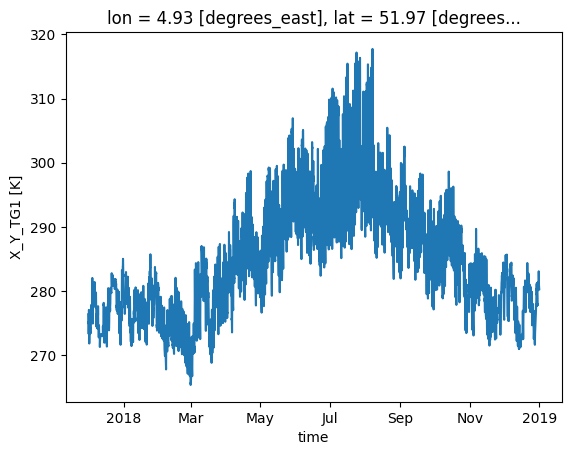

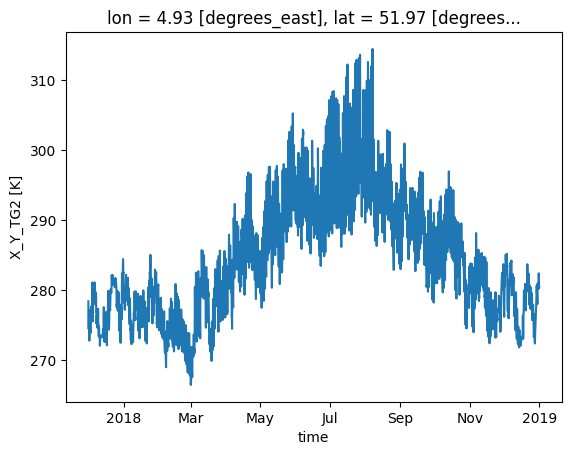

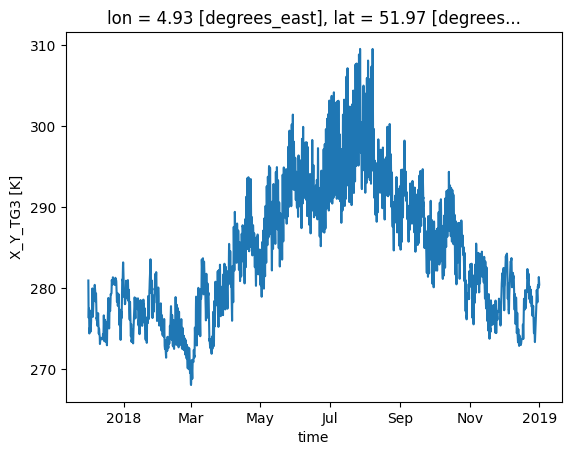

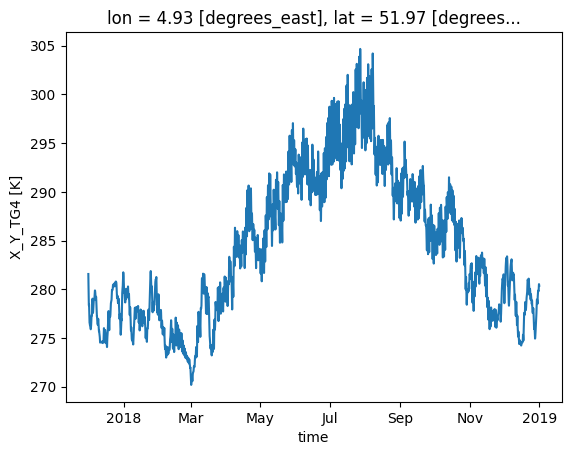

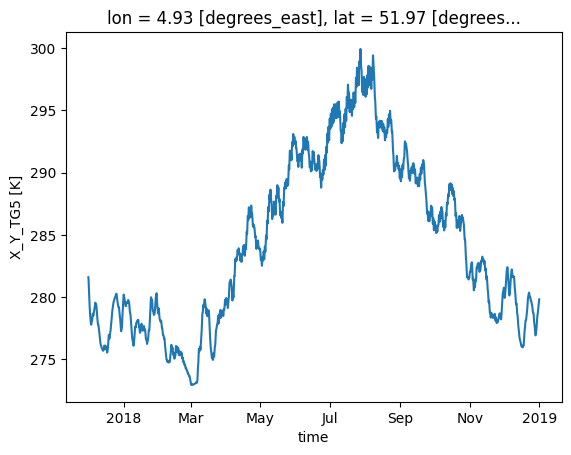

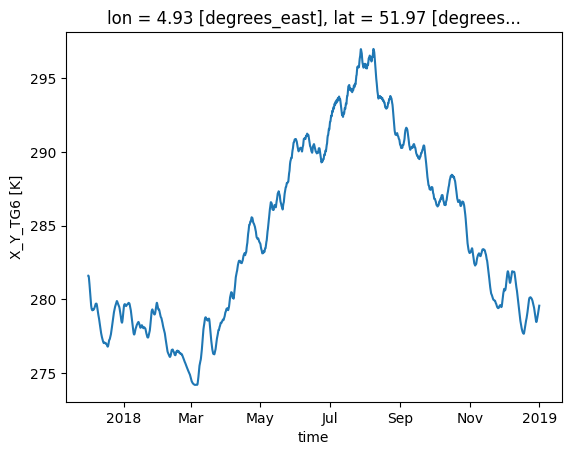

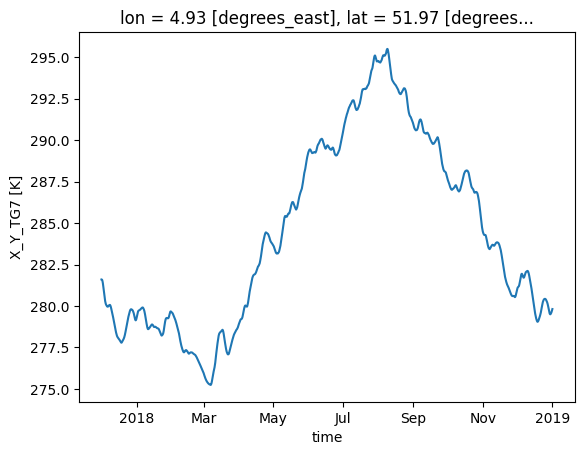

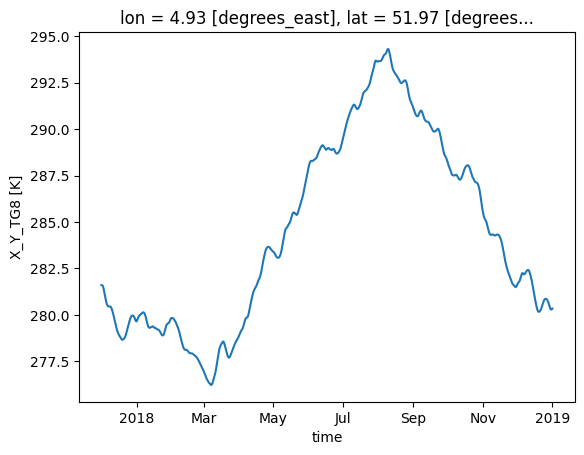

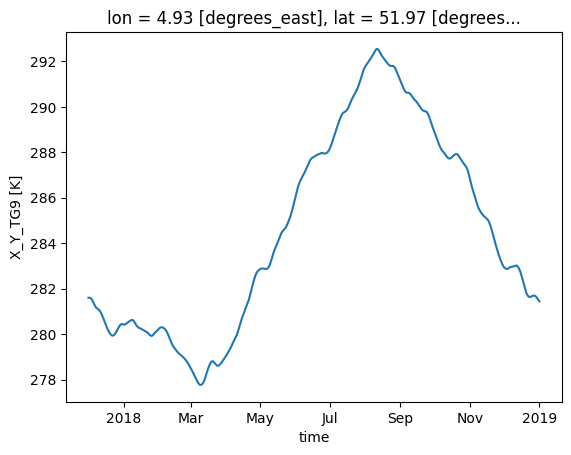

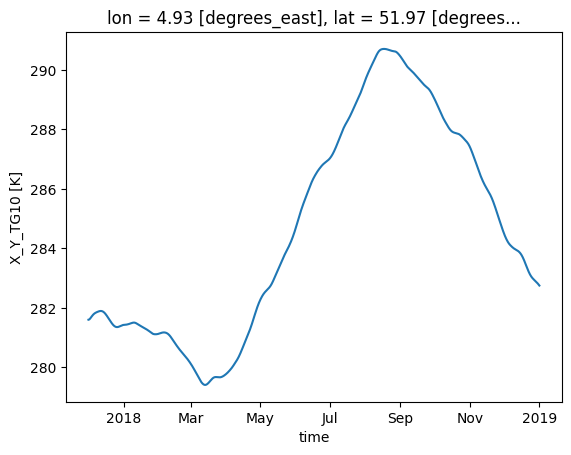

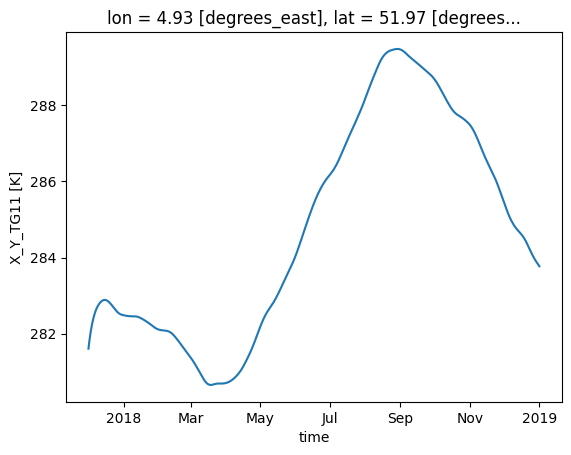

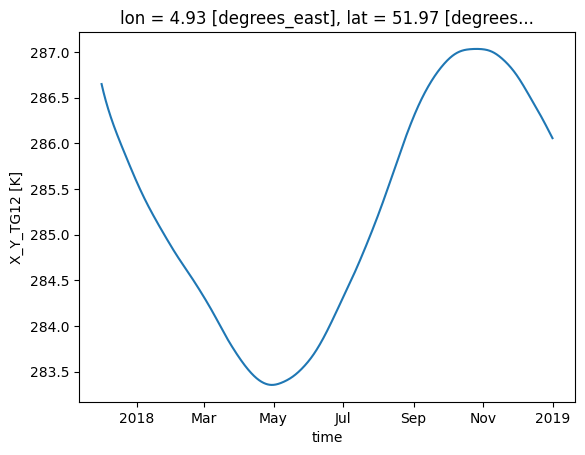

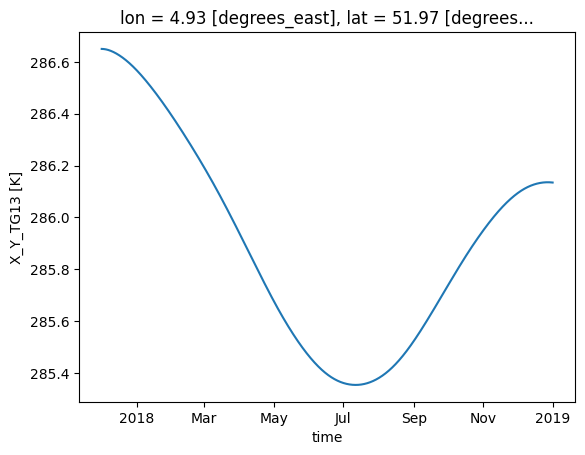

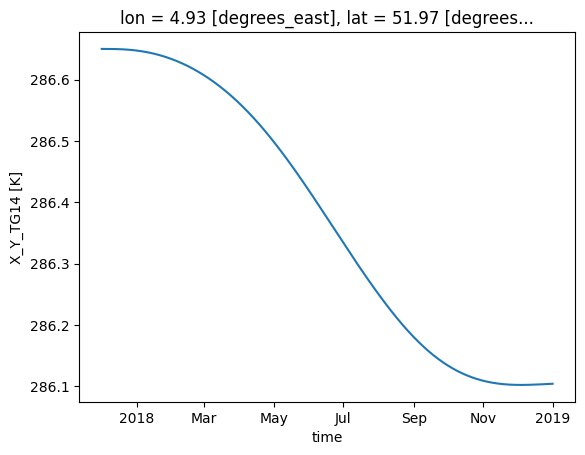

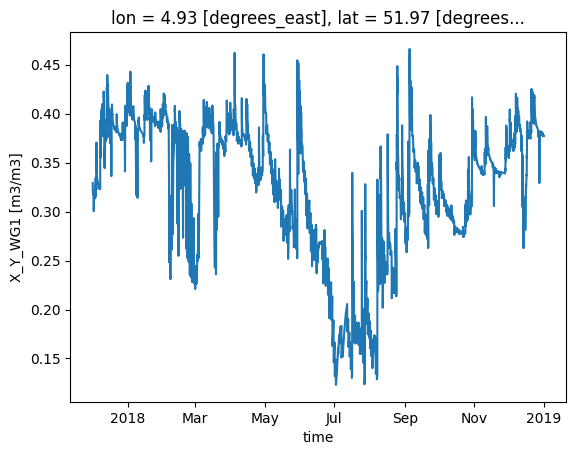

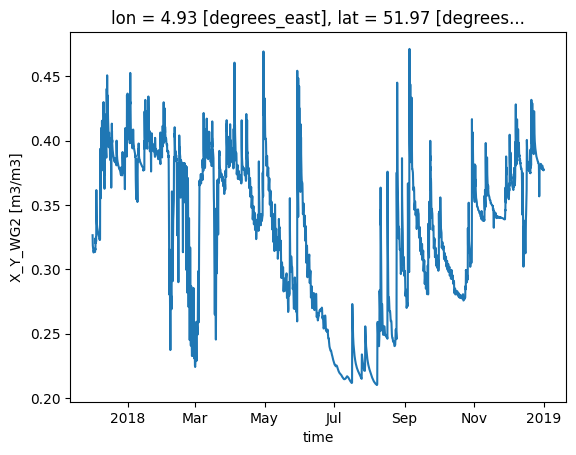

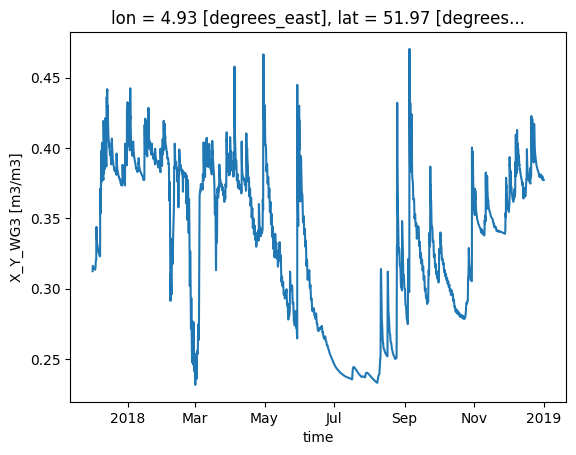

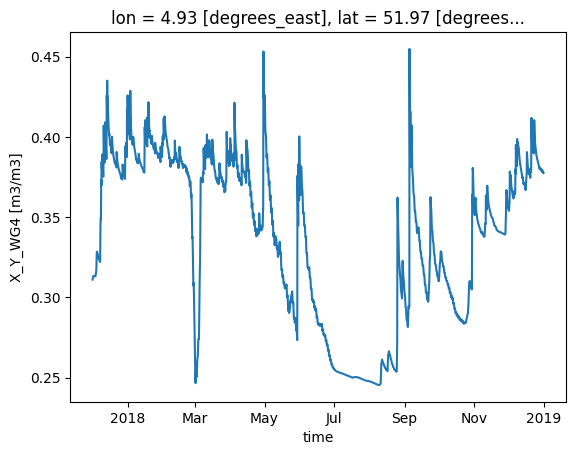

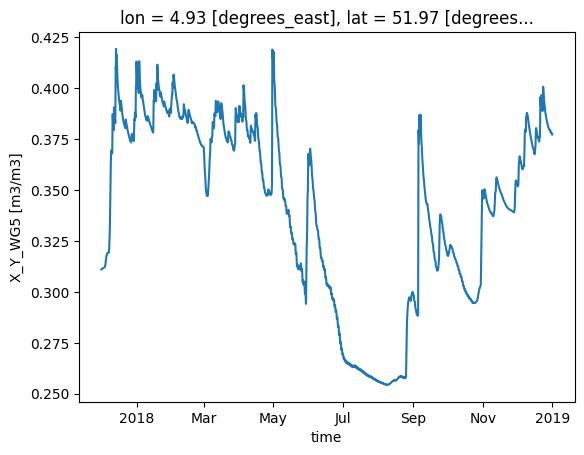

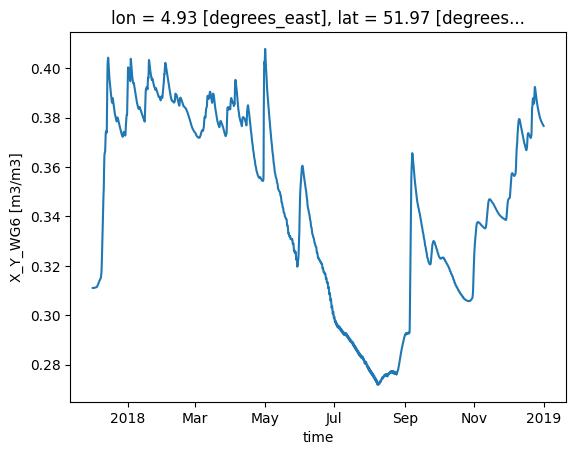

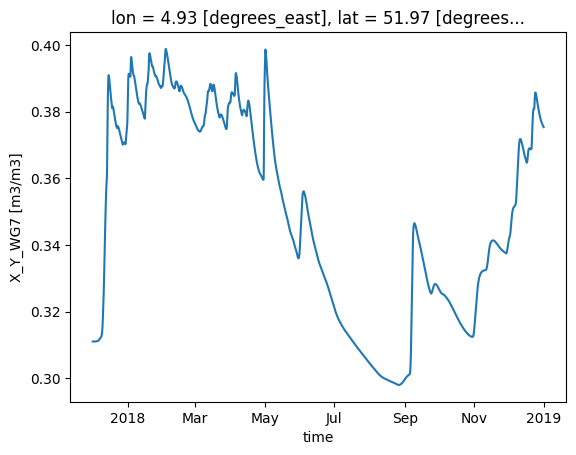

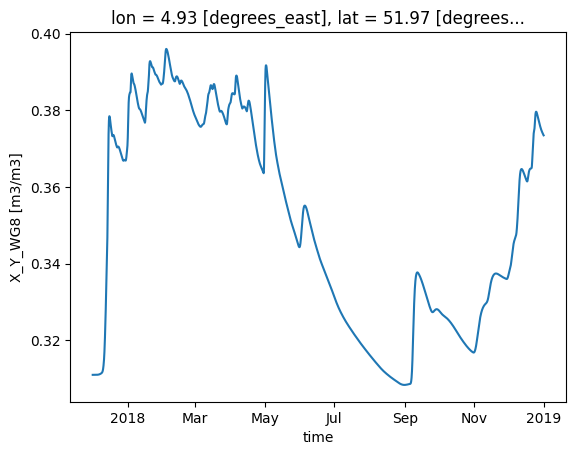

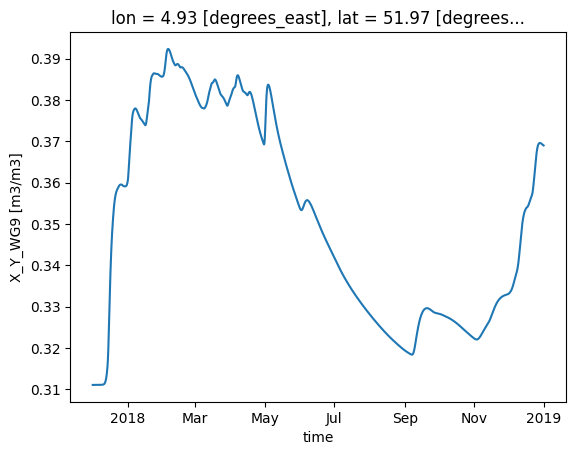

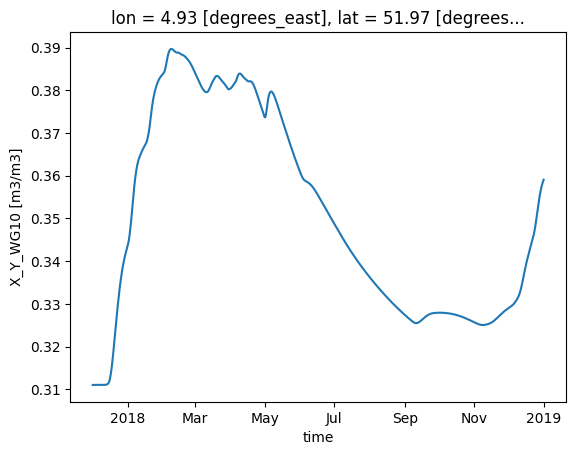

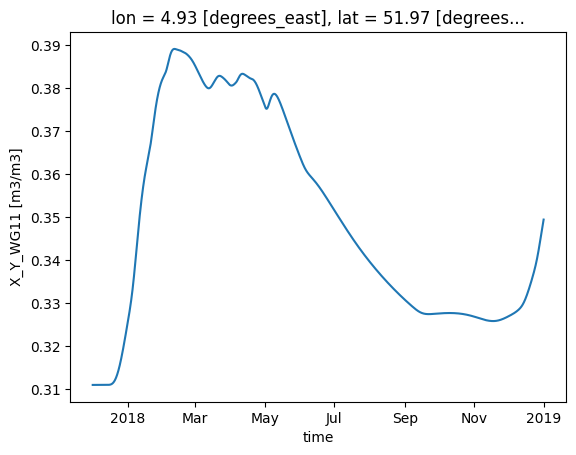

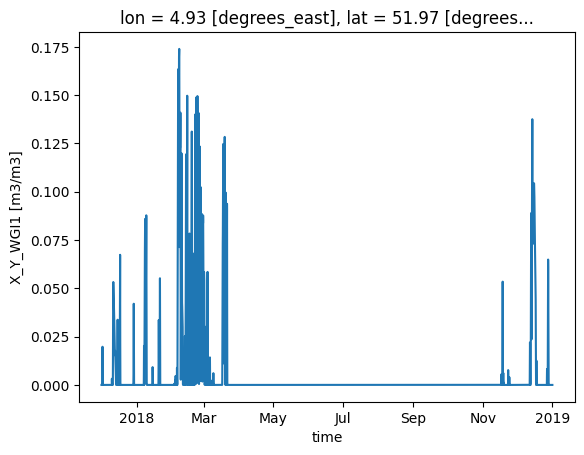

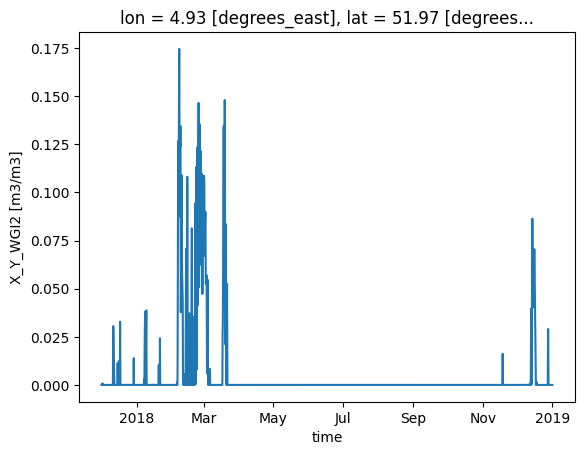

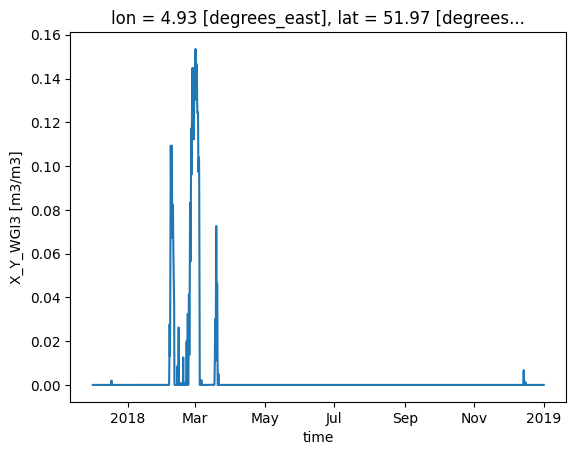

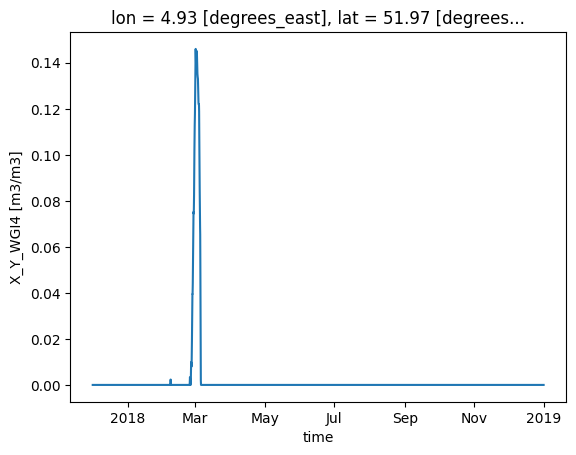

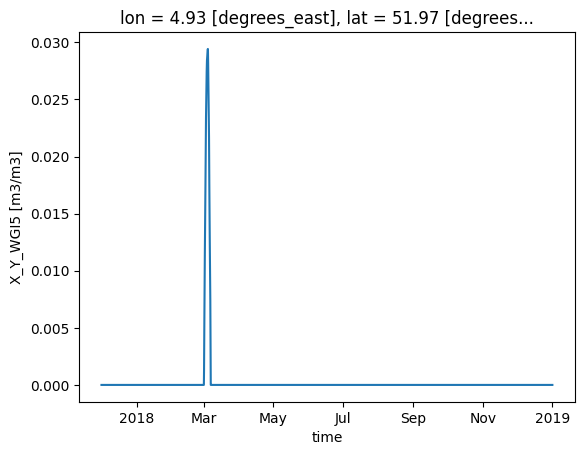

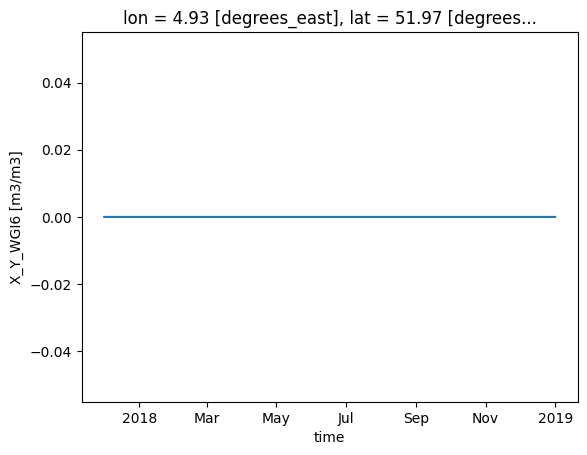

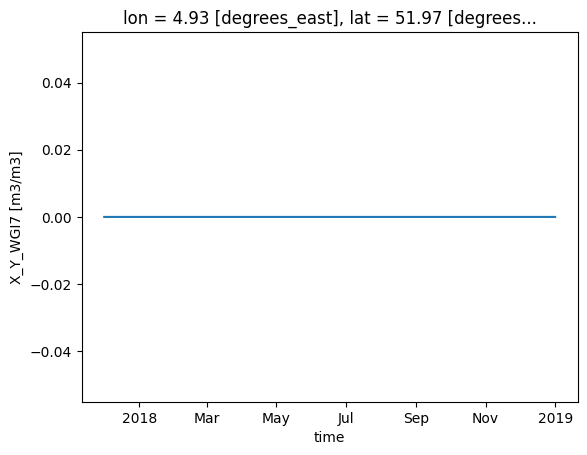

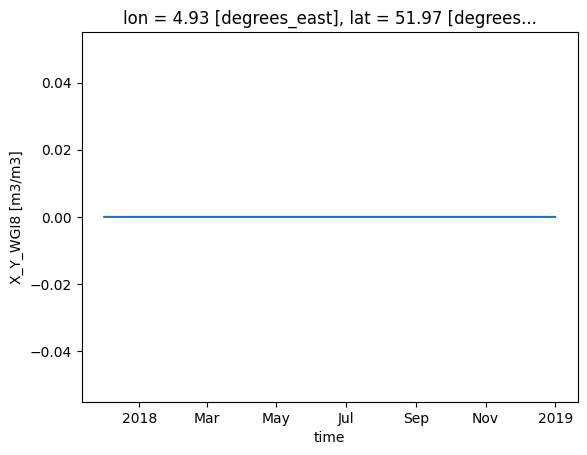

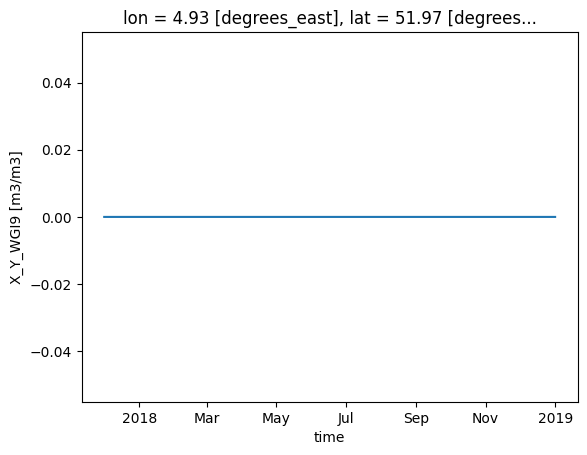

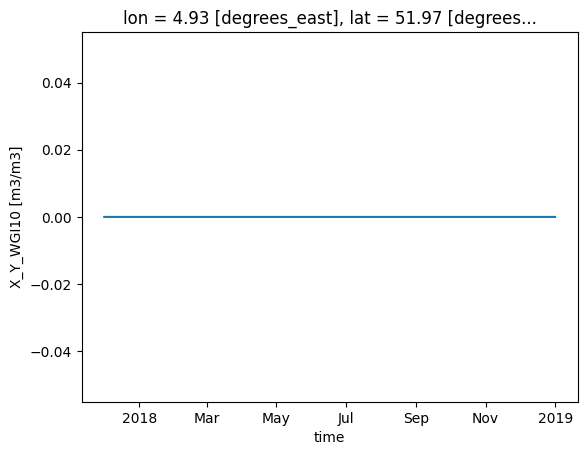

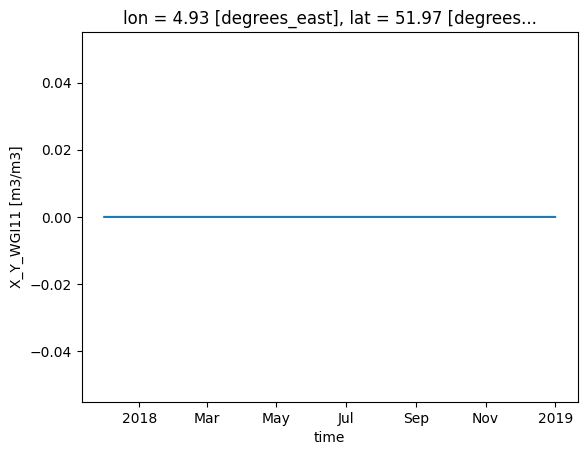

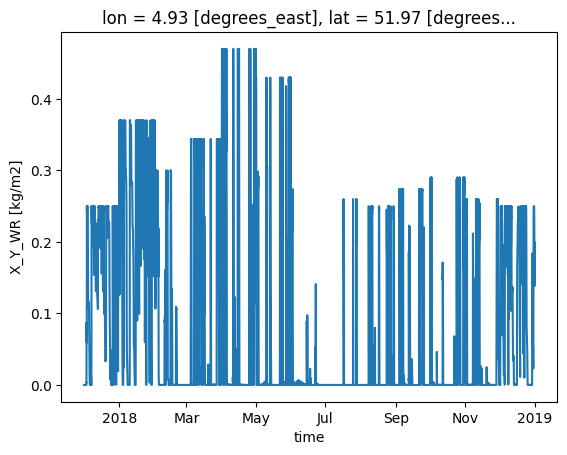

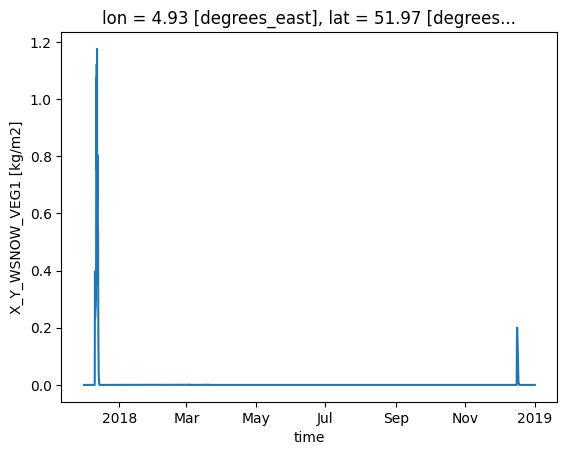

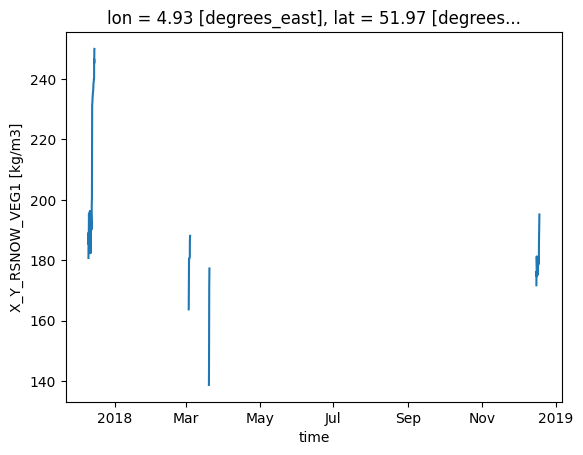

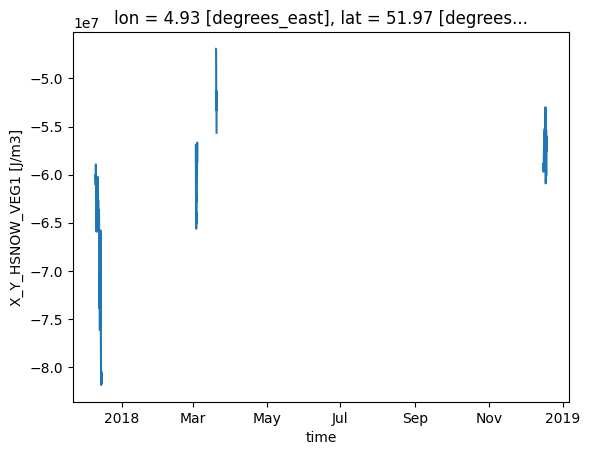

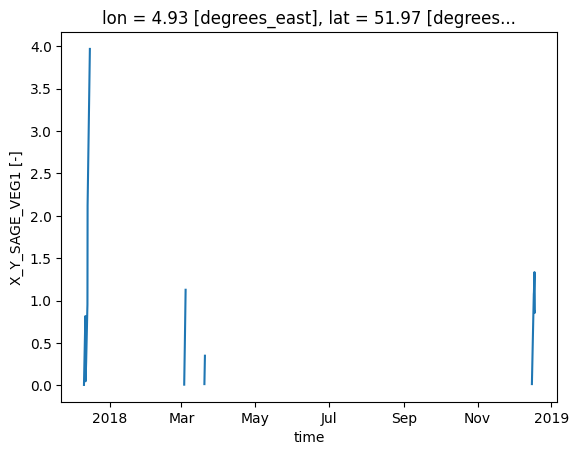

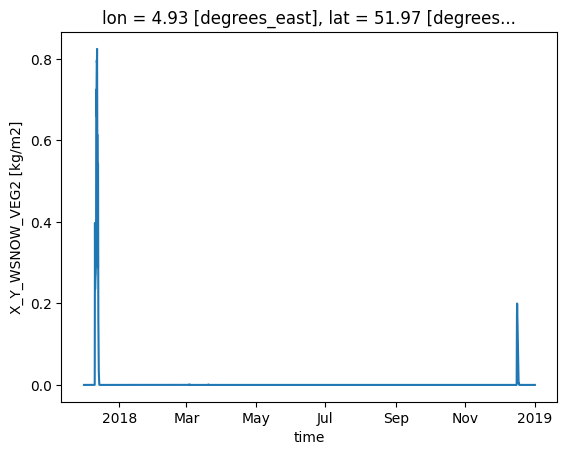

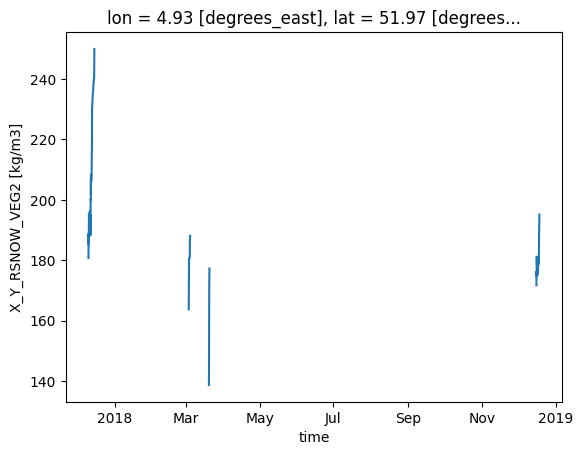

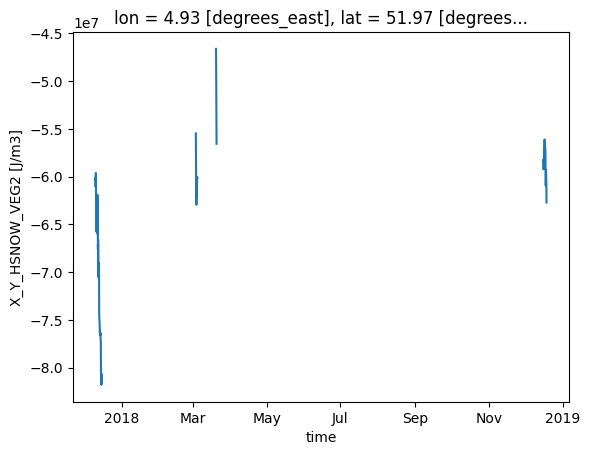

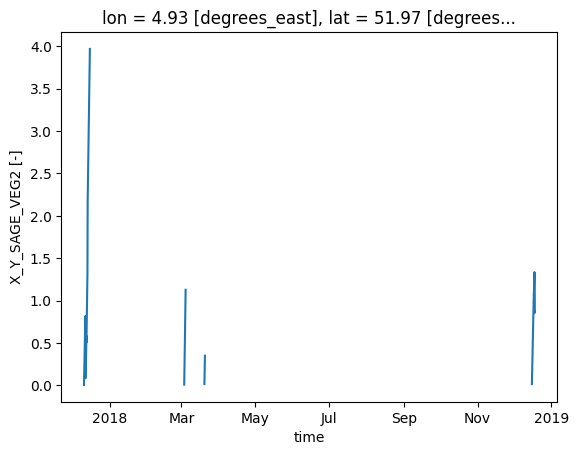

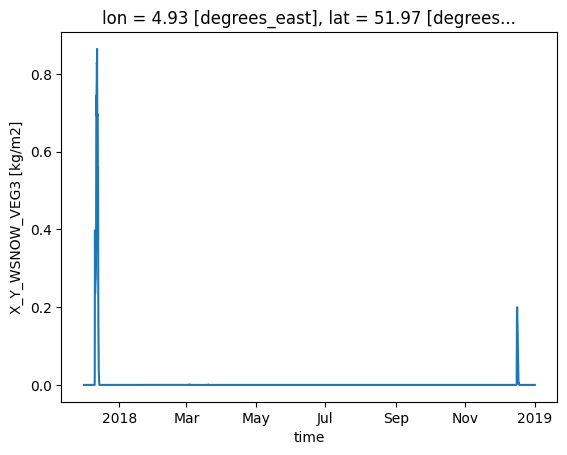

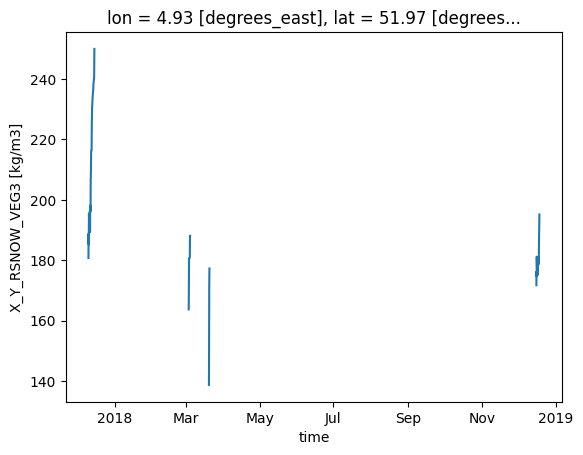

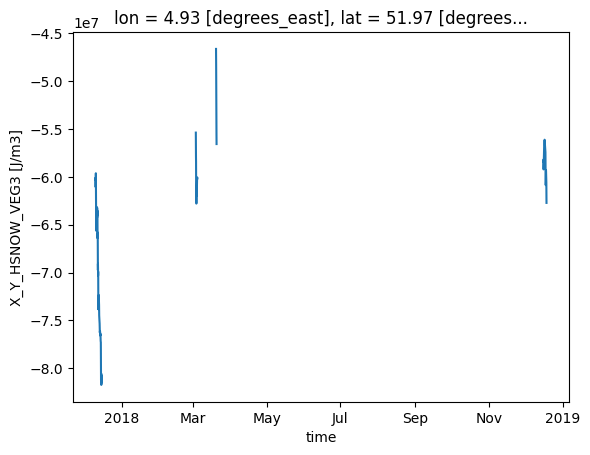

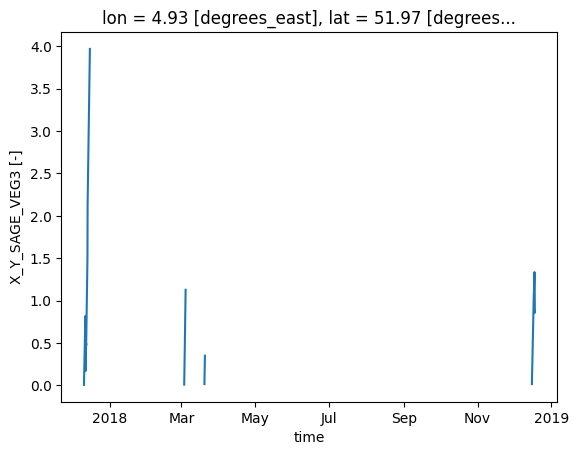

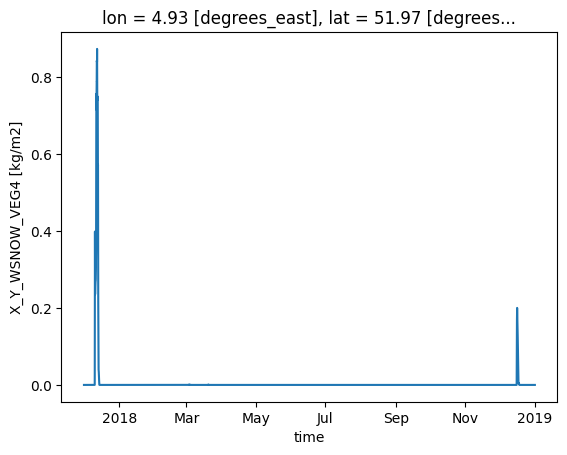

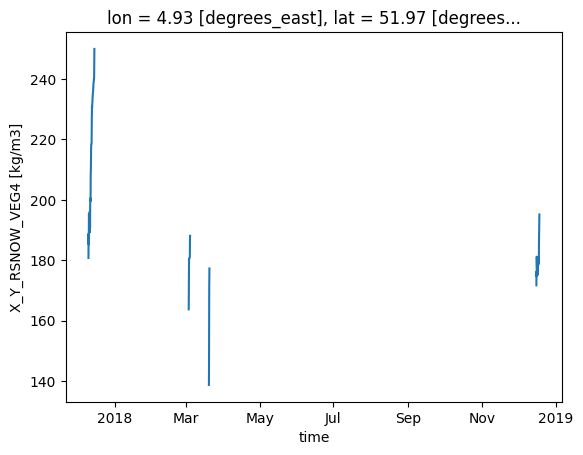

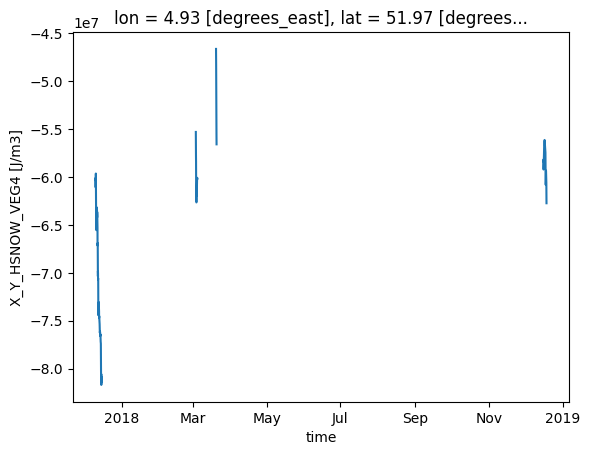

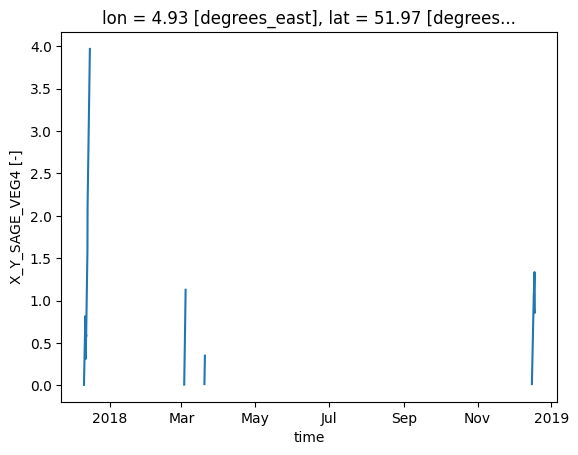

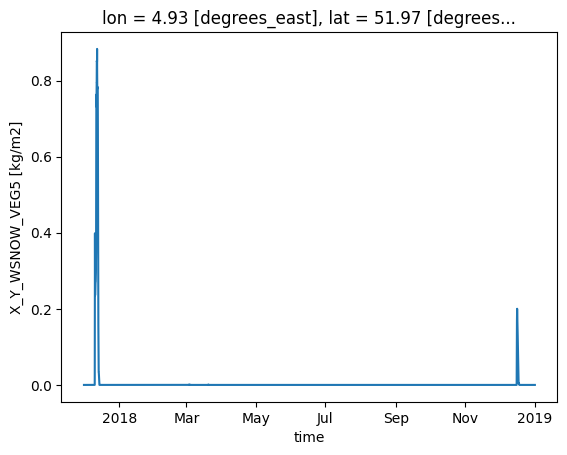

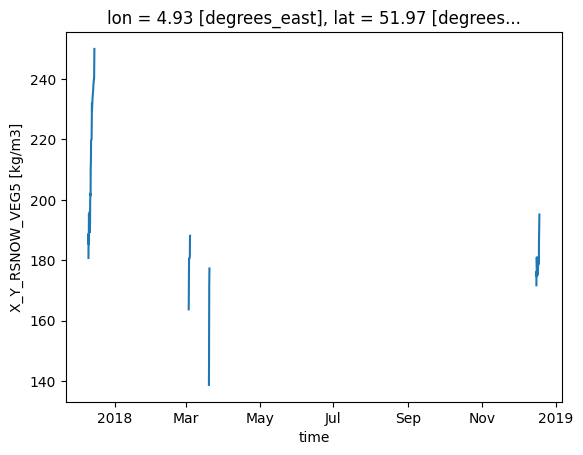

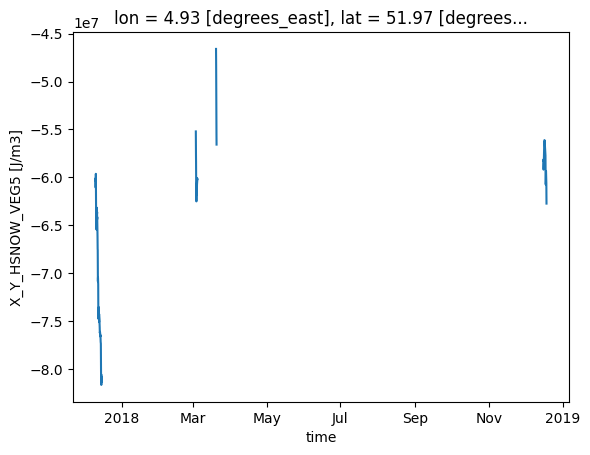

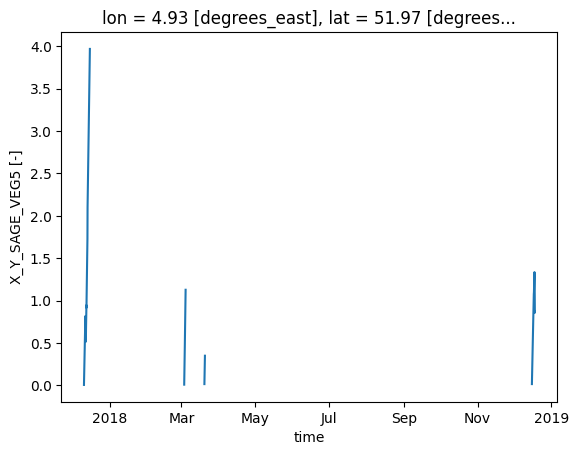

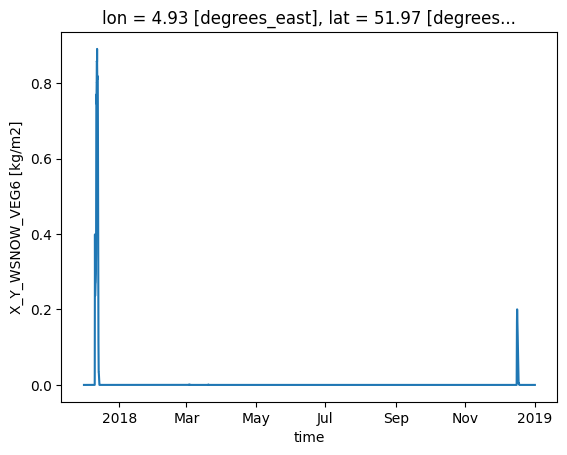

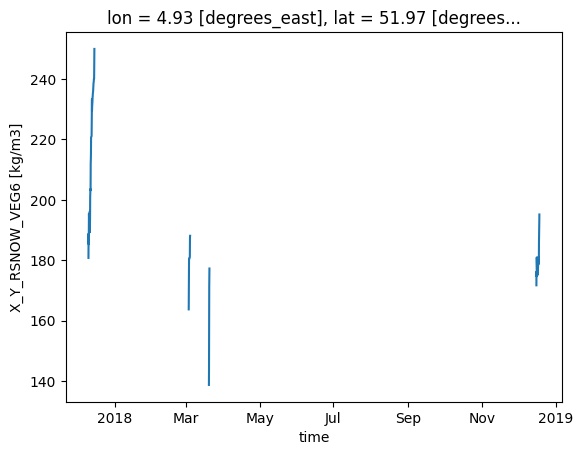

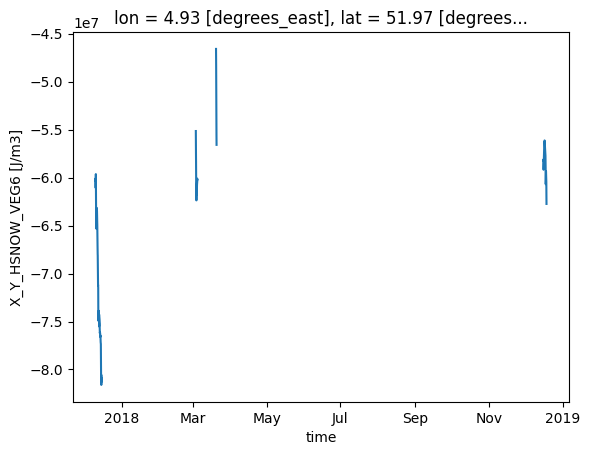

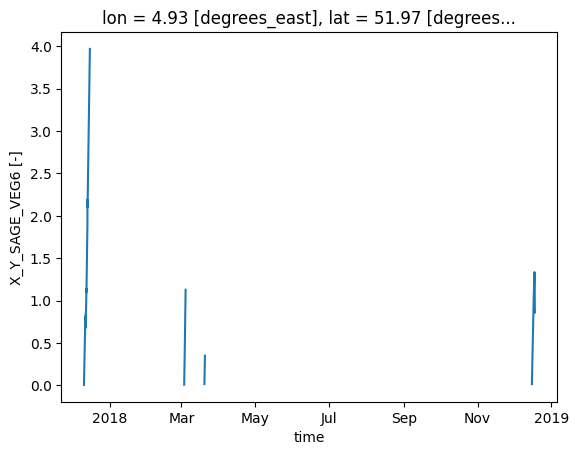

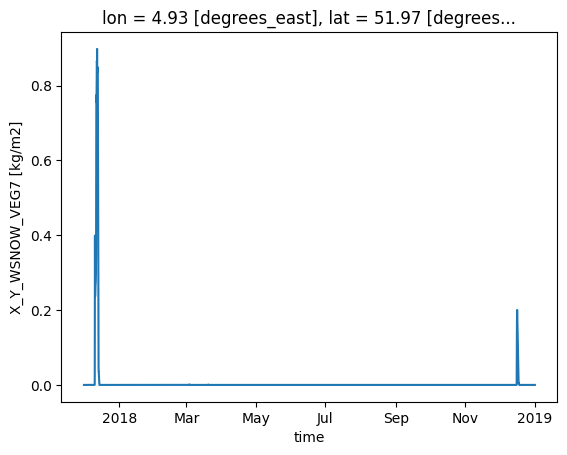

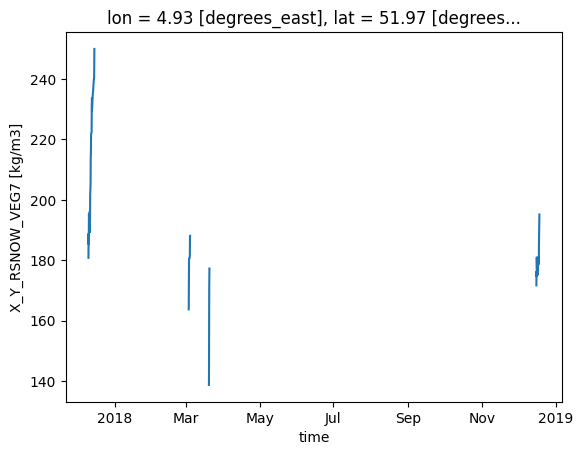

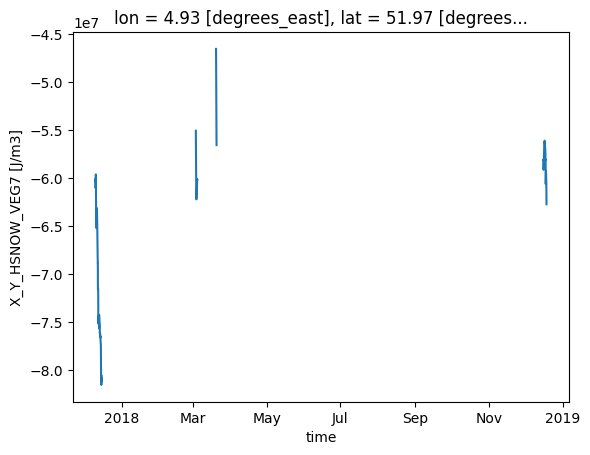

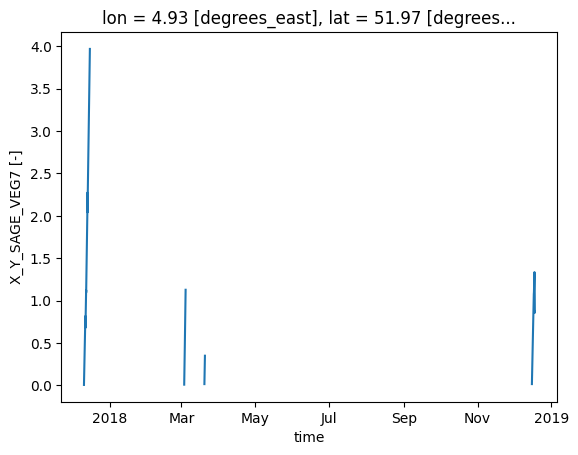

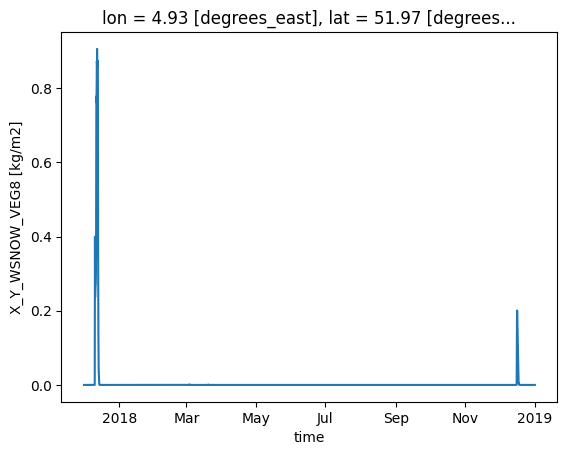

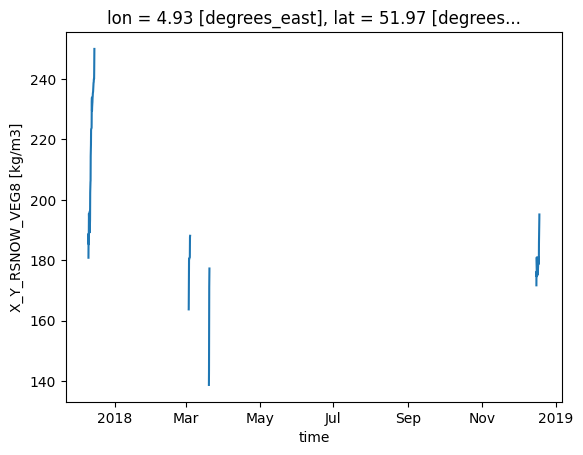

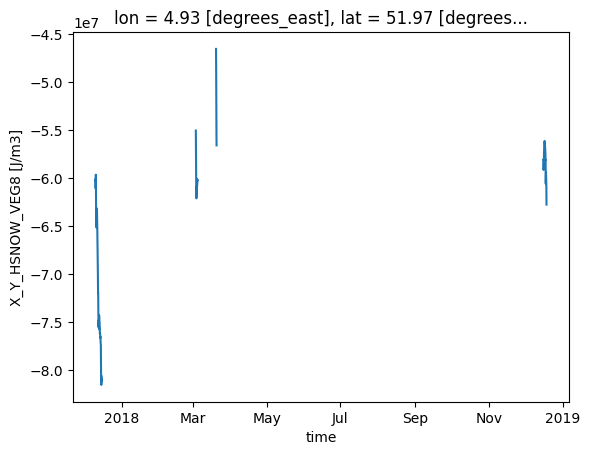

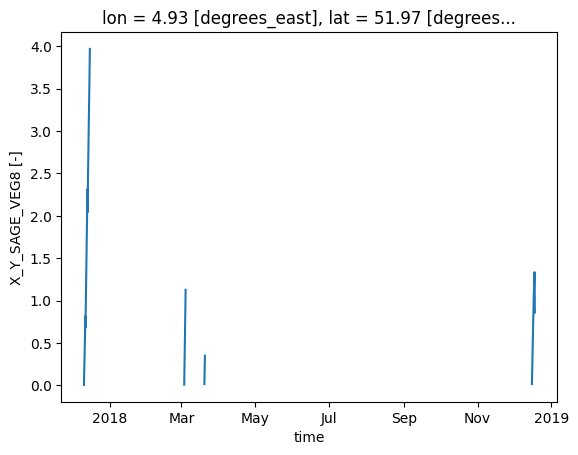

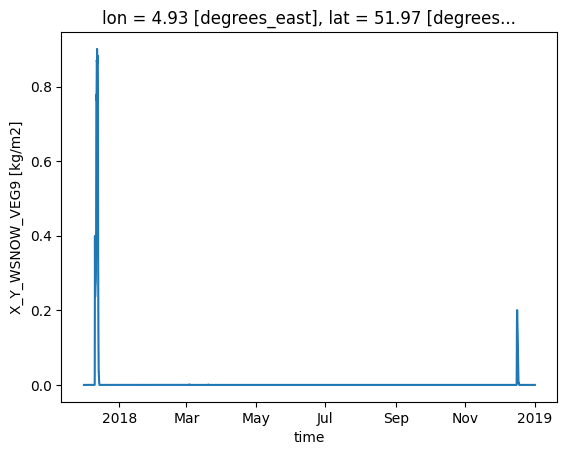

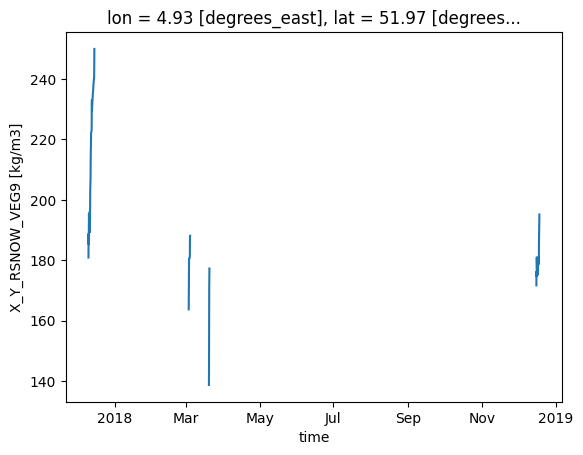

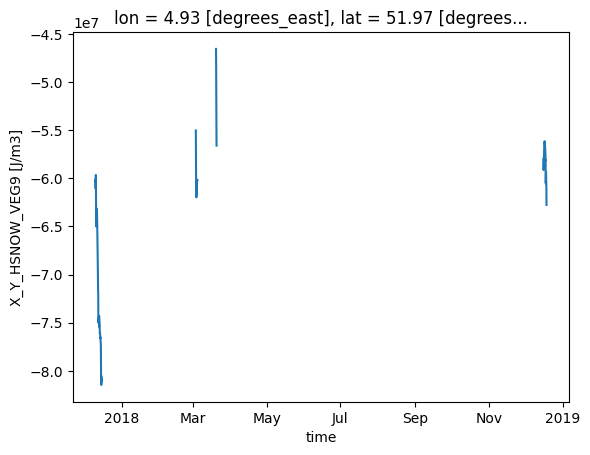

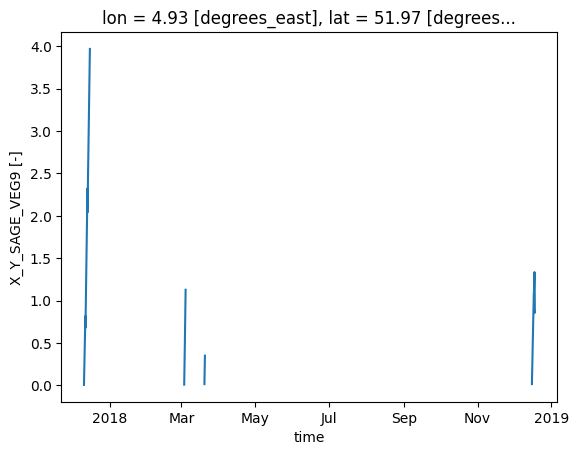

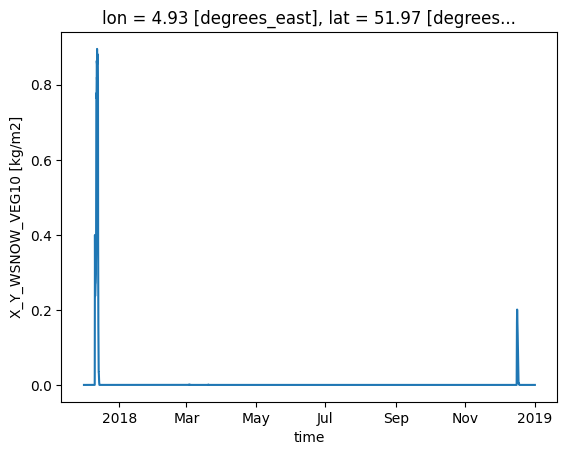

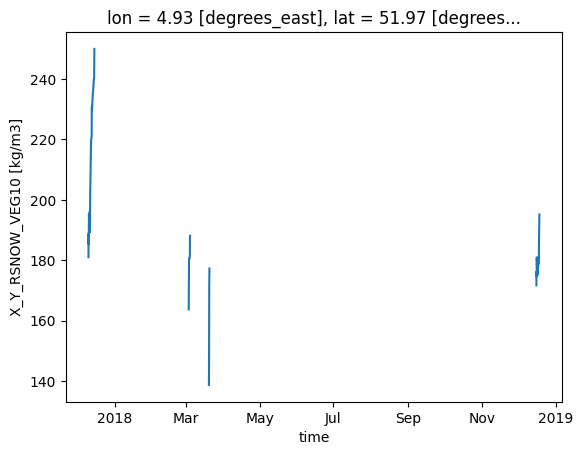

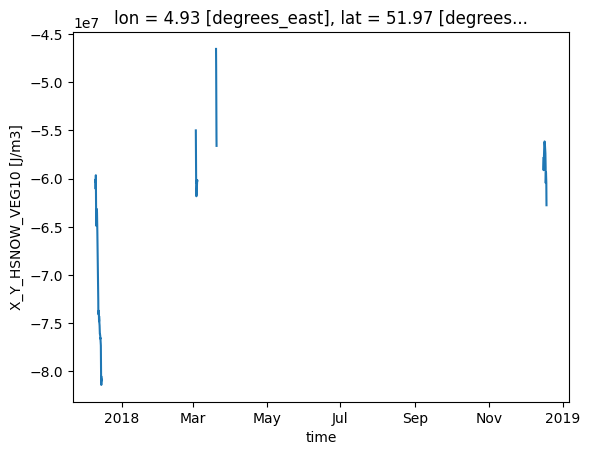

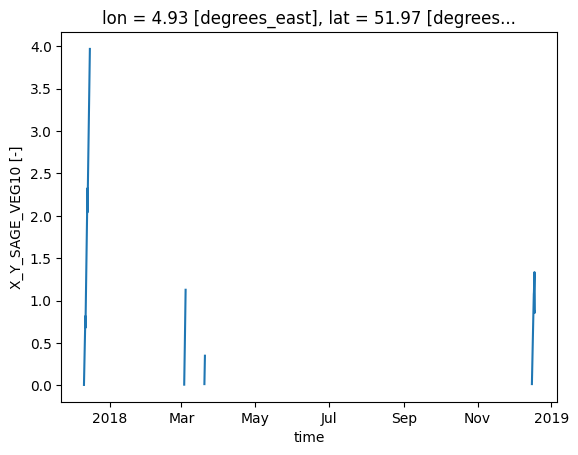

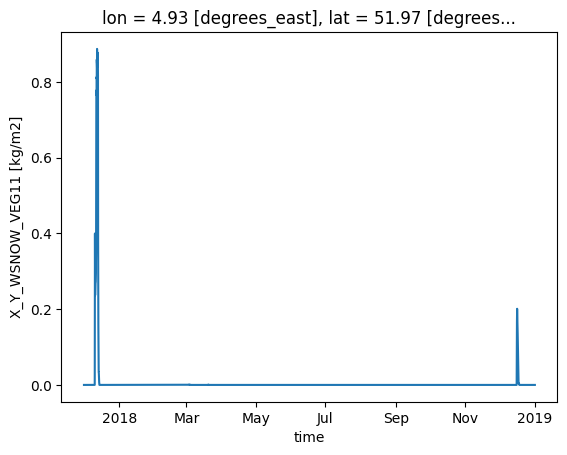

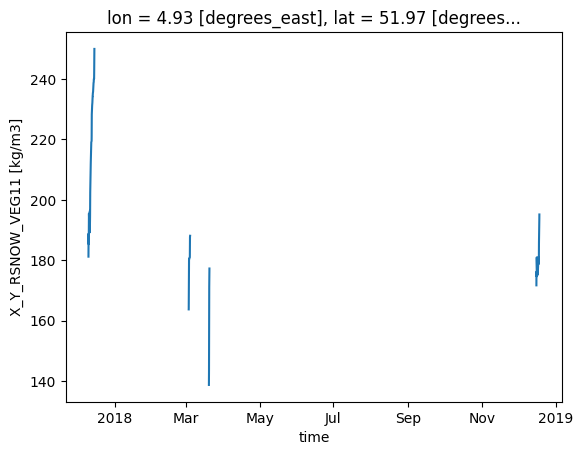

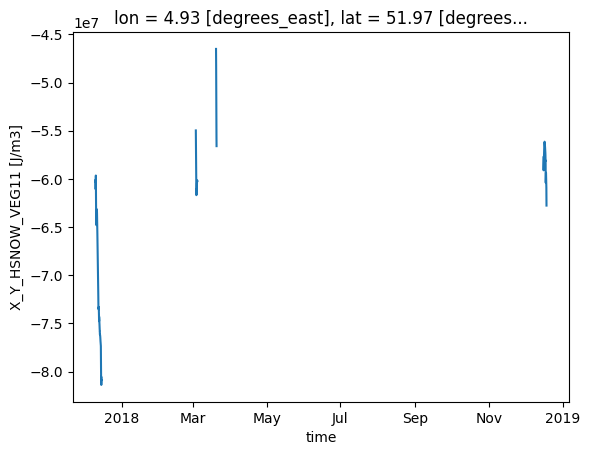

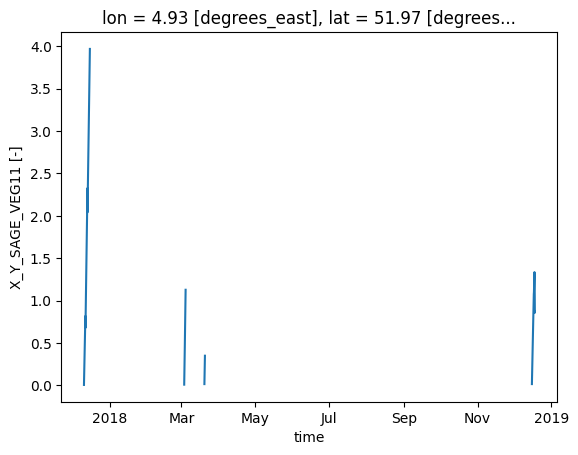

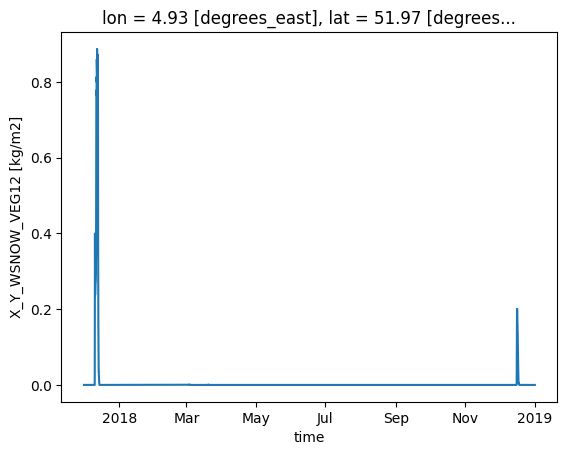

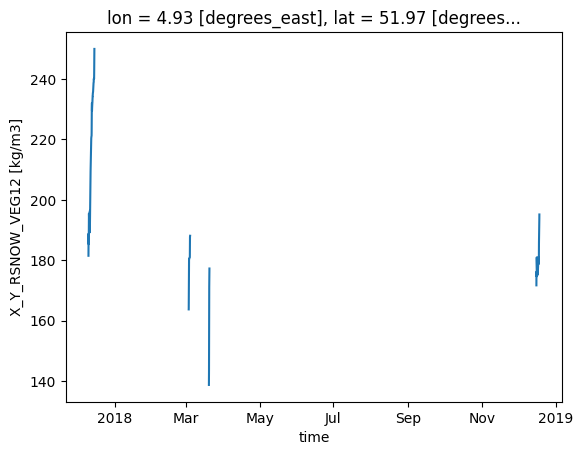

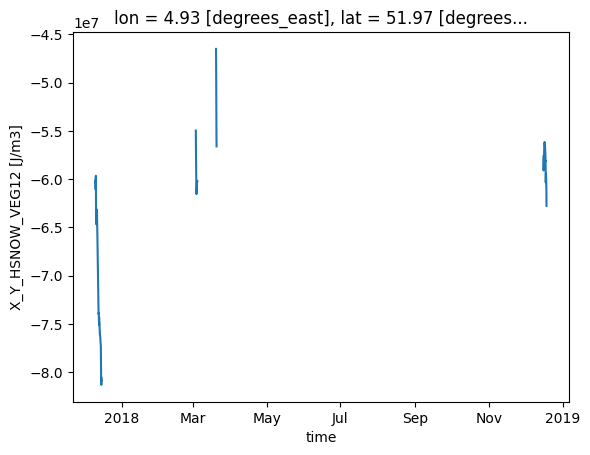

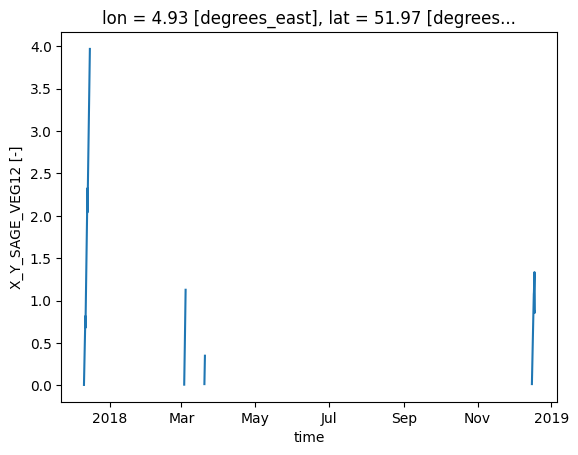

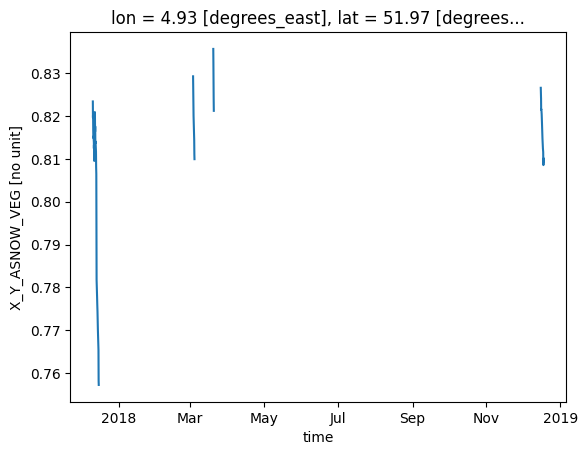

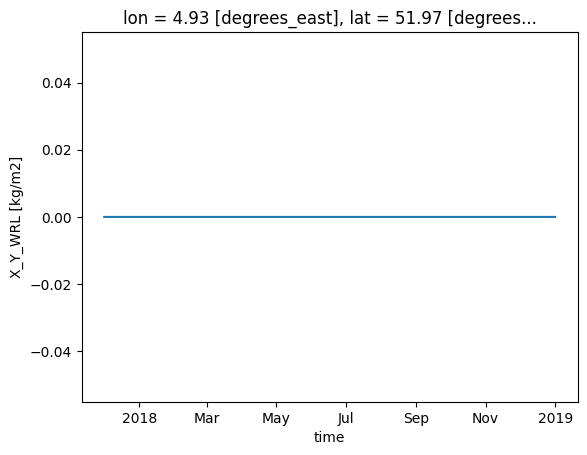

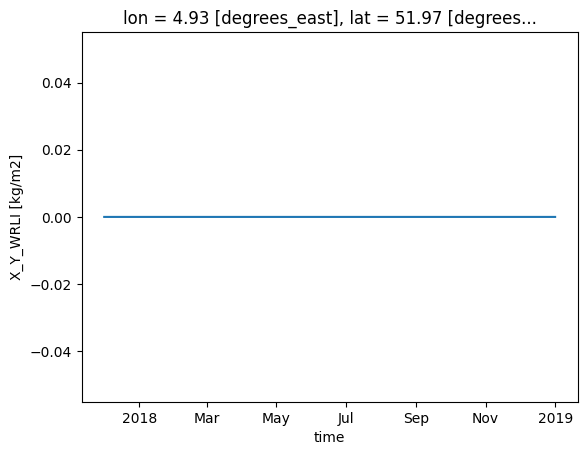

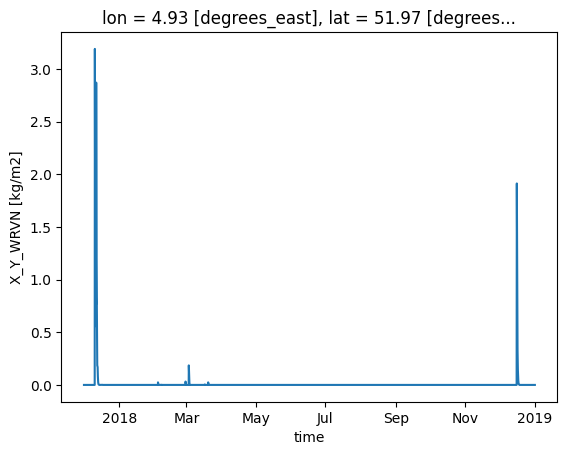

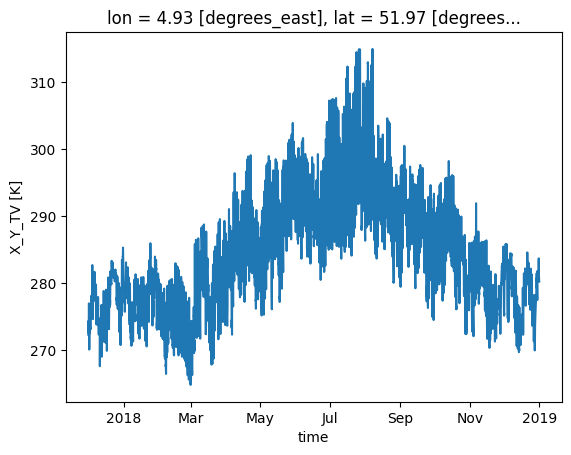

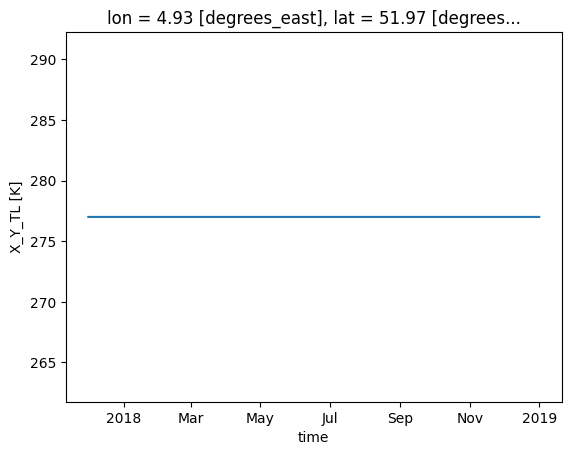

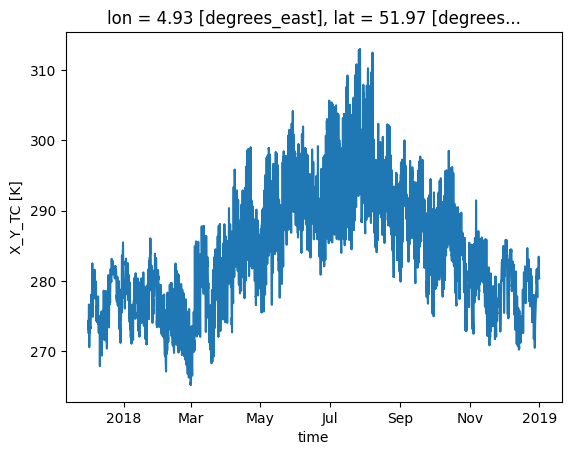

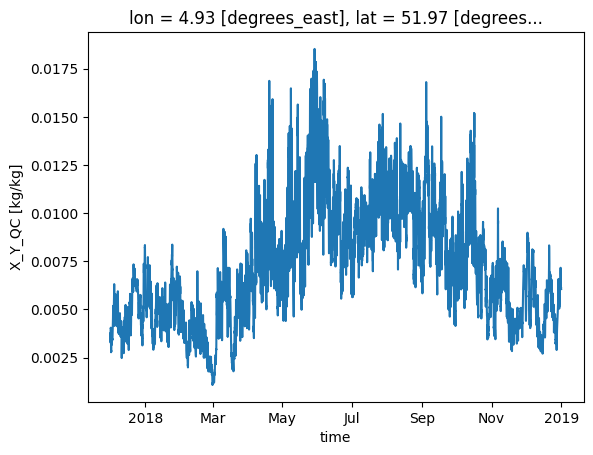

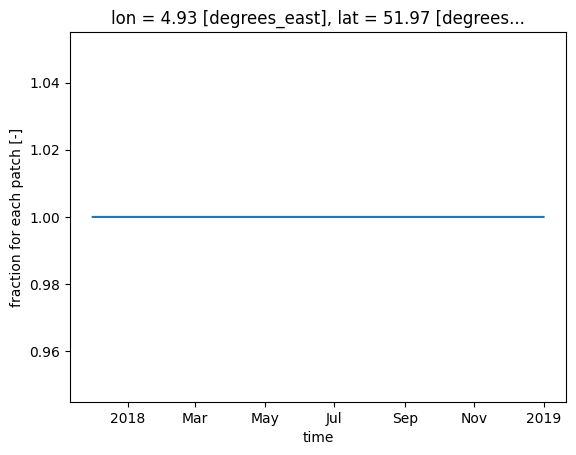

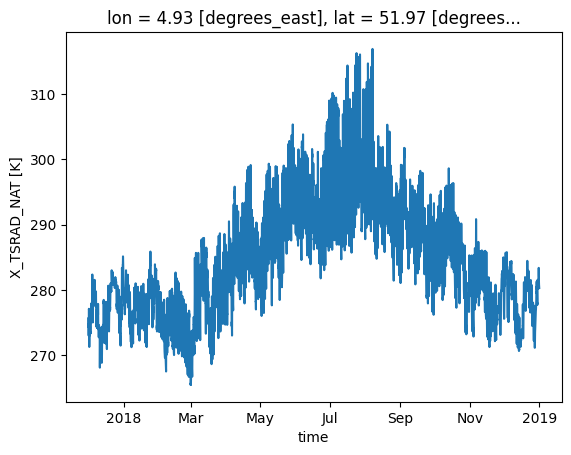

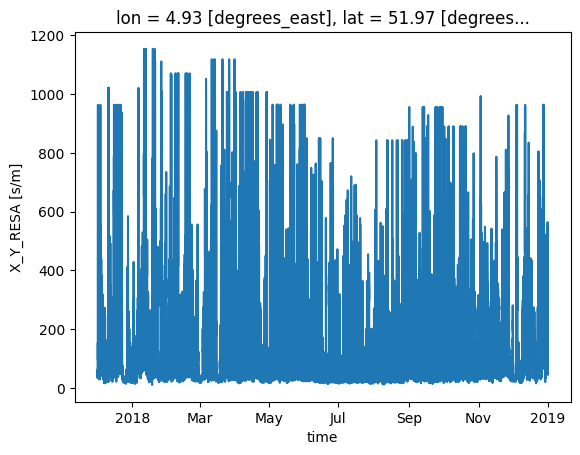

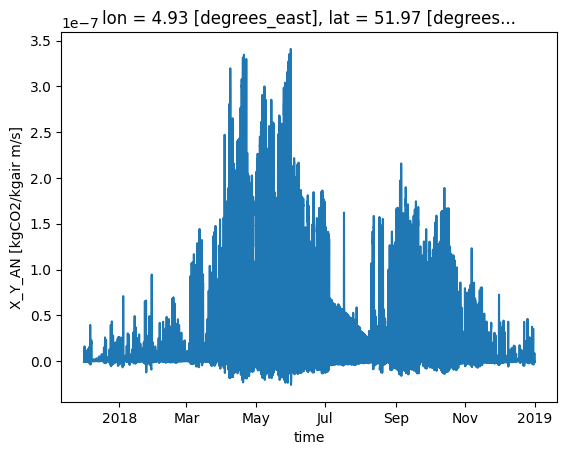

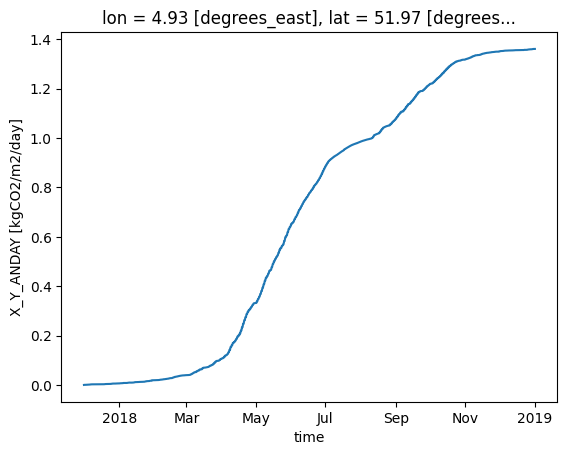

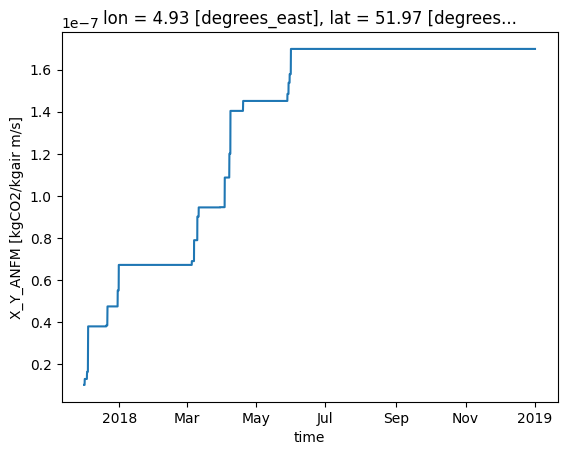

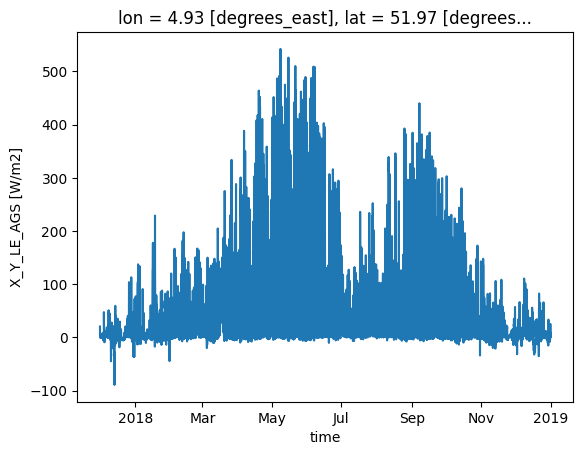

In [218]:
for v in ds.data_vars:
    try:
        ds[v].plot()
        plt.title = v
        plt.show()
    except:
        pass